In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("cleaned_reviews.csv")

# Create brand features
print("Creating brand features...")

brand_features = df.groupby('brand').agg(
    total_reviews = ('review_id', 'count'),
    avg_rating = ('rating', 'mean'),
    total_thumbs_up = ('thumbs_up', 'sum'),
    positive_reviews = ('sentiment', lambda x: (x == 'Positive').sum()),
    negative_reviews = ('sentiment', lambda x: (x == 'Negative').sum()),
    neutral_reviews = ('sentiment', lambda x: (x == 'Neutral').sum()),
).reset_index()

# Additional features
brand_features['positive_ratio'] = (
    brand_features['positive_reviews'] / brand_features['total_reviews']
)
brand_features['negative_ratio'] = (
    brand_features['negative_reviews'] / brand_features['total_reviews']
)
brand_features['engagement_score'] = (
    brand_features['total_thumbs_up'] / brand_features['total_reviews']
)

print("Brand features:")
print(brand_features)


Creating brand features...
Brand features:
     brand  total_reviews  avg_rating  total_thumbs_up  positive_reviews  \
0  Blinkit          47597    4.069206             3197             36434   
1     CRED          47699    4.068450            37081             36699   
2   Meesho          47569    4.215981             8992             38344   
3      Ola          48395    2.926356            23609             22758   
4    Paytm          46205    4.253133            15262             37638   
5  PhonePe          46639    4.449945             7303             40519   
6   Swiggy          47196    3.408530             8819             28234   
7     Uber          48481    3.932056            12625             35241   
8    Zepto          48453    3.317607            17228             27918   
9   Zomato          46986    4.114268             3120             36810   

   negative_reviews  neutral_reviews  positive_ratio  negative_ratio  \
0              9041             2122        0.76

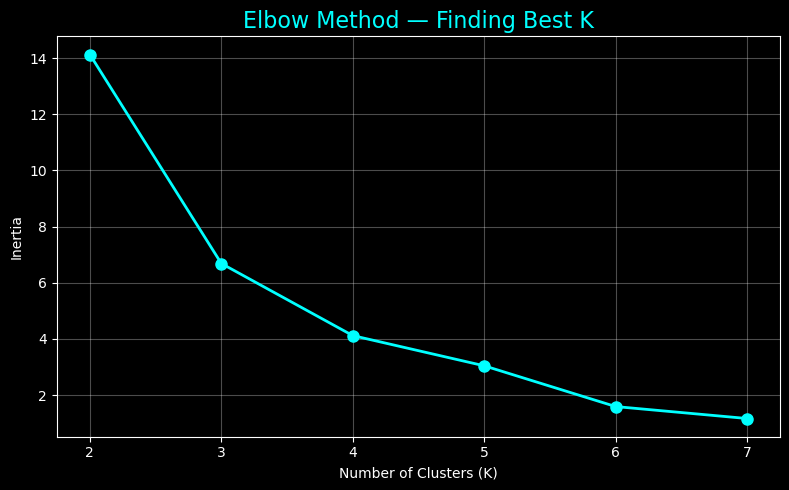

Look for the ELBOW point in the curve!


In [4]:
# Select features for clustering
features = ['avg_rating', 'positive_ratio', 'negative_ratio', 'engagement_score']
X = brand_features[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.style.use('dark_background')
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='cyan', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Best K', color='cyan', fontsize=16)
plt.xlabel('Number of Clusters (K)', color='white')
plt.ylabel('Inertia', color='white')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Look for the ELBOW point in the curve!")

In [5]:
# Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
brand_features['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters
cluster_labels = {0: 'Top Performers', 1: 'Struggling Brands', 2: 'Middle Ground'}
brand_features['cluster_name'] = brand_features['cluster'].map(cluster_labels)

# Show results
print("Brand Clusters:")
print(brand_features[['brand', 'avg_rating', 'positive_ratio', 
                        'negative_ratio', 'cluster_name']])

# Save
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('cluster_scaler.pkl', 'wb'))
print("\nModel saved!")

Brand Clusters:
     brand  avg_rating  positive_ratio  negative_ratio       cluster_name
0  Blinkit    4.069206        0.765468        0.189949  Struggling Brands
1     CRED    4.068450        0.769387        0.206608      Middle Ground
2   Meesho    4.215981        0.806071        0.176754  Struggling Brands
3      Ola    2.926356        0.470255        0.498791     Top Performers
4    Paytm    4.253133        0.814587        0.157299  Struggling Brands
5  PhonePe    4.449945        0.868779        0.091318  Struggling Brands
6   Swiggy    3.408530        0.598229        0.363145     Top Performers
7     Uber    3.932056        0.726903        0.246385  Struggling Brands
8    Zepto    3.317607        0.576187        0.402493     Top Performers
9   Zomato    4.114268        0.783425        0.175116  Struggling Brands

Model saved!


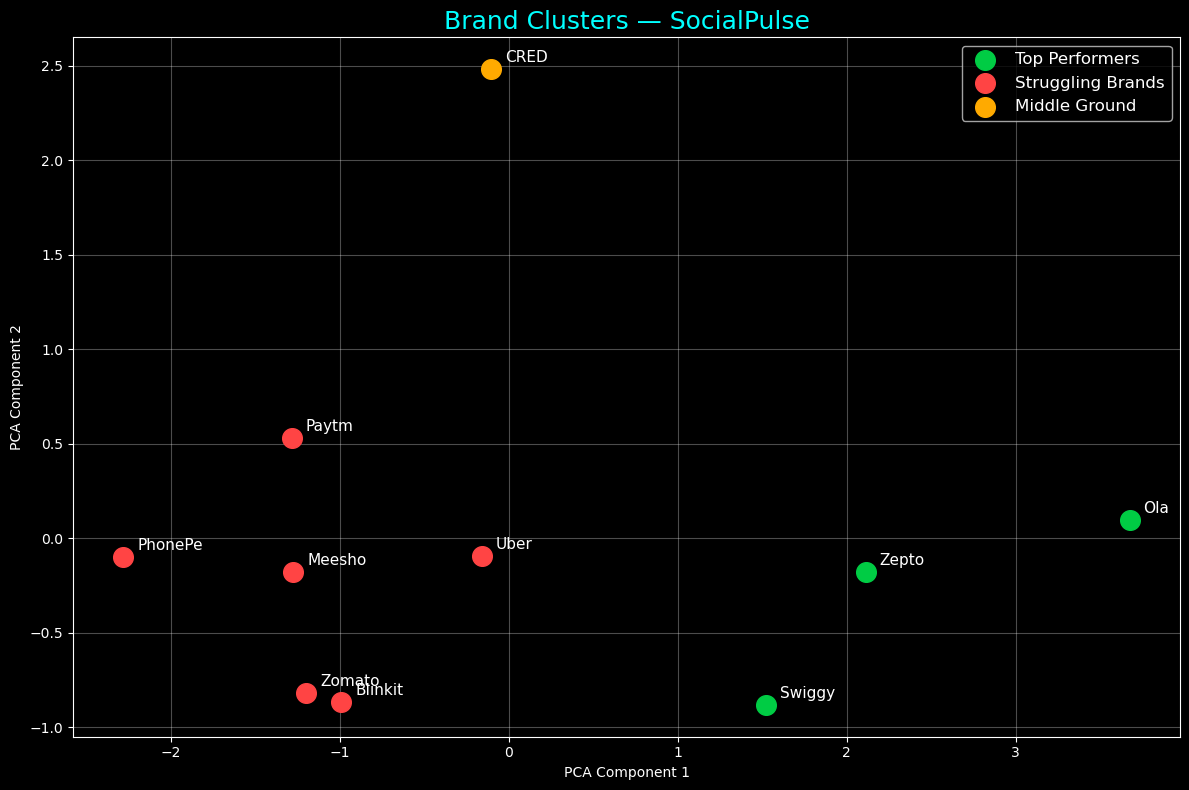

In [6]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#00cc44', '#ff4444', '#ffaa00']
cluster_names = ['Top Performers', 'Struggling Brands', 'Middle Ground']

for i in range(3):
    mask = brand_features['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[i], s=200, label=cluster_names[i], zorder=5)
    
    # Add brand name labels
    for idx in brand_features[mask].index:
        ax.annotate(brand_features.loc[idx, 'brand'],
                   (X_pca[idx, 0], X_pca[idx, 1]),
                   textcoords="offset points",
                   xytext=(10, 5),
                   fontsize=11,
                   color='white')

ax.set_title('Brand Clusters — SocialPulse', color='cyan', fontsize=18)
ax.set_xlabel('PCA Component 1', color='white')
ax.set_ylabel('PCA Component 2', color='white')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('brand_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(brand_features[['brand', 'avg_rating', 'positive_ratio', 
                        'negative_ratio', 'engagement_score', 'cluster_name']].sort_values('cluster_name'))

     brand  avg_rating  positive_ratio  negative_ratio  engagement_score  \
1     CRED    4.068450        0.769387        0.206608          0.777396   
0  Blinkit    4.069206        0.765468        0.189949          0.067168   
2   Meesho    4.215981        0.806071        0.176754          0.189031   
4    Paytm    4.253133        0.814587        0.157299          0.330311   
5  PhonePe    4.449945        0.868779        0.091318          0.156586   
7     Uber    3.932056        0.726903        0.246385          0.260411   
9   Zomato    4.114268        0.783425        0.175116          0.066403   
3      Ola    2.926356        0.470255        0.498791          0.487840   
6   Swiggy    3.408530        0.598229        0.363145          0.186859   
8    Zepto    3.317607        0.576187        0.402493          0.355561   

        cluster_name  
1      Middle Ground  
0  Struggling Brands  
2  Struggling Brands  
4  Struggling Brands  
5  Struggling Brands  
7  Struggling Brands  
9 

In [8]:
# Calculate average rating per cluster to correctly label them
cluster_summary = brand_features.groupby('cluster')['avg_rating'].mean().sort_values(ascending=False)
print("Cluster performance ranking:")
print(cluster_summary)

# Auto-assign correct labels based on actual avg_rating
sorted_clusters = cluster_summary.index.tolist()
correct_labels = {
    sorted_clusters[0]: 'Top Performers',
    sorted_clusters[1]: 'Middle Ground', 
    sorted_clusters[2]: 'Struggling Brands'
}

brand_features['cluster_name'] = brand_features['cluster'].map(correct_labels)

print("\nCorrected Brand Clusters:")
print(brand_features[['brand', 'avg_rating', 'positive_ratio', 
                        'negative_ratio', 'engagement_score', 'cluster_name']].sort_values('avg_rating', ascending=False))

Cluster performance ranking:
cluster
1    4.172432
2    4.068450
0    3.217498
Name: avg_rating, dtype: float64

Corrected Brand Clusters:
     brand  avg_rating  positive_ratio  negative_ratio  engagement_score  \
5  PhonePe    4.449945        0.868779        0.091318          0.156586   
4    Paytm    4.253133        0.814587        0.157299          0.330311   
2   Meesho    4.215981        0.806071        0.176754          0.189031   
9   Zomato    4.114268        0.783425        0.175116          0.066403   
0  Blinkit    4.069206        0.765468        0.189949          0.067168   
1     CRED    4.068450        0.769387        0.206608          0.777396   
7     Uber    3.932056        0.726903        0.246385          0.260411   
6   Swiggy    3.408530        0.598229        0.363145          0.186859   
8    Zepto    3.317607        0.576187        0.402493          0.355561   
3      Ola    2.926356        0.470255        0.498791          0.487840   

        cluster_name  
5

In [9]:
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('cluster_scaler.pkl', 'wb'))
brand_features.to_csv('brand_clusters.csv', index=False)
print("Saved kmeans_model.pkl, cluster_scaler.pkl, and brand_clusters.csv")

Saved kmeans_model.pkl, cluster_scaler.pkl, and brand_clusters.csv
